In [2]:
from pathlib import Path
from ebs_dataset_loader import (
    discover_ebs_samples,
    load_ebs_dataset,
    extract_sensor_cubes,
)
from functions import *

DATASET_ROOT = Path('/home/arbash44/coding/hsi/polymers/EBS_only/EBS12_EBS22')
print(DATASET_ROOT)

/home/arbash44/coding/hsi/polymers/EBS_only/EBS12_EBS22


In [3]:
# Load the full dataset (set load_instance=True if you need SAM instances now)
records = load_ebs_dataset(
    dataset_root=DATASET_ROOT,
    classes=['Styrene', 'PP', 'PA', 'PC', 'mix'],
    load_fenix=True,
    load_fx50=True,
    load_dtree=True,
    load_semantic_mask=True,
    load_instance=True,  # change to True if you need instance masks loaded
    load_rgb = True,
)

print(f'Loaded records: {len(records)}')
print('Keys in one record:', records[0].keys()) 

/opt/conda/lib/python3.8/site-packages/spectral/io/envi.py:175: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loaded records: 13
Keys in one record: dict_keys(['class_name', 'sample_name', 'sample_dir', 'fenix_cube', 'fx50_cube', 'dTree_mask', 'semantic_mask', 'instances', 'rgb_cube'])


In [4]:
# Extract only cubes (this is usually what you pass to models)
fenix_cubes, fenix_labels, fenix_names = extract_sensor_cubes(records, sensor='FENIX')
fx50_cubes, fx50_labels, fx50_names = extract_sensor_cubes(records, sensor='FX50')
RGB_cubes, RGB_labels, RGB_names = extract_sensor_cubes(records, sensor='RGB')

print('FENIX cubes:', len(fenix_cubes))
print('FX50 cubes:', len(fx50_cubes))

if fenix_cubes:
    print('FENIX cube shape example:', fenix_cubes[0].shape, np.max(fenix_cubes[0]))
if fx50_cubes:
    print('FX50 cube shape example:', fx50_cubes[0].shape)
if RGB_cubes:
    print('RGB shape example:', RGB_cubes[0].shape)

FENIX cubes: 13
FX50 cubes: 13
FENIX cube shape example: (640, 1114, 450) 0.8658731
FX50 cube shape example: (640, 1114, 308)
RGB shape example: (640, 1114, 3)


In [5]:
gt = []
semantic_masks = []
instance_masks = []
for i in range(len(records)):
    print(fenix_names[i])
    print(fx50_names[i])
    gt.append(records[i]["dTree_mask"])
    semantic_masks.append(records[i]["semantic_mask"].astype(bool))
    instance_masks.append(records[i]["instances"])
    print(gt[0].shape,semantic_masks[0].shape)

EBS12_11mm_5mm_Styrole2
EBS12_11mm_5mm_Styrole2
(640, 1114) (640, 1114)
EBS22_SLF_Styrole2
EBS22_SLF_Styrole2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PP2
EBS12_11mm_5mm_PP2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PP2
EBS12_30mm_5mm_PP2
(640, 1114) (640, 1114)
EBS22_SLF_PP2
EBS22_SLF_PP2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PA2
EBS12_11mm_5mm_PA2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PA2
EBS12_30mm_5mm_PA2
(640, 1114) (640, 1114)
EBS22_SLF_PA2
EBS22_SLF_PA2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PC2
EBS12_11mm_5mm_PC2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PC2
EBS12_30mm_5mm_PC2
(640, 1114) (640, 1114)
EBS22_SLF_PC2
EBS22_SLF_PC2
(640, 1114) (640, 1114)
1
1
(640, 1114) (640, 1114)
2
2
(640, 1114) (640, 1114)


In [6]:
# Sorting cubes to classes
Styrene_FENIX = fenix_cubes[:2]
Styrene_FX = fx50_cubes[:2]
Styrene_gt = gt[:2]
Styrene_semantic_masks = semantic_masks[:2]
Styrene_instance = instance_masks[:2]
print('Styrene: ', len(Styrene_FX), len(Styrene_gt), len(Styrene_semantic_masks), len(Styrene_instance))

PA_FENIX = fenix_cubes[5:8]
PA_FX = fx50_cubes[5:8]
PA_gt = gt[5:8]
PA_semantic_masks = semantic_masks[5:8]
PA_instance = instance_masks[5:8]
print('PA: ', len(PA_FX), len(PA_gt), len(PA_semantic_masks), len(PA_instance))

PC_FENIX = fenix_cubes[8:11]
PC_FX = fx50_cubes[8:11]
PC_gt = gt[8:11]
PC_semantic_masks = semantic_masks[8:11]
PC_instance = instance_masks[8:11]
print('PC: ', len(PC_FX), len(PC_gt), len(PC_semantic_masks), len(PC_instance))


PP_FENIX = fenix_cubes[2:5]
PP_FX = fx50_cubes[2:5]
PP_gt = gt[2:5]
PP_semantic_masks = semantic_masks[2:5]
PP_instance = instance_masks[2:5]
print('PP: ', len(PP_FX), len(PP_gt), len(PP_semantic_masks), len(PP_instance))

Mix_FENIX = fenix_cubes[11:]
Mix_FX = fx50_cubes[11:]
Mix_gt = gt[11:]
Mix_semantic_masks = semantic_masks[11:]
Mix_instance = instance_masks[11:]
print('Mix: ', len(Mix_FX), len(Mix_gt), len(Mix_semantic_masks), len(Mix_instance))



Styrene:  2 2 2 2
PA:  3 3 3 3
PC:  3 3 3 3
PP:  3 3 3 3
Mix:  2 2 2 2


In [7]:
# Normalizing the cubes
Styrene_FENIX_norm = [snv_normalize(i) for i in Styrene_FENIX]
print("Styrene_FENIX_norm Done !")
Styrene_FX_norm = [snv_normalize(i) for i in Styrene_FX]
print("Styrene_FX_norm Done !")
PP_FENIX_norm = [snv_normalize(i) for i in PP_FENIX]
print("PP_FENIX_norm Done !")
PP_FX_norm = [snv_normalize(i) for i in PP_FX]
print("PP_FX_norm Done !")
PA_FENIX_norm = [snv_normalize(i) for i in PA_FENIX]
print("PA_FENIX_norm Done !")
PA_FX_norm = [snv_normalize(i) for i in PA_FX]
print("PA_FX_norm Done !")
PC_FENIX_norm = [snv_normalize(i) for i in PC_FENIX]
print("PC_FENIX_norm Done !")
PC_FX_norm = [snv_normalize(i) for i in PC_FX]
print("PC_FX_norm Done !")
Mix_FENIX_norm = [snv_normalize(i) for i in Mix_FENIX]
print("Mix_FENIX_norm Done !")
Mix_FX_norm = [snv_normalize(i) for i in Mix_FX]
print("Mix_FX_norm Done !")


Styrene_FENIX_norm Done !
Styrene_FX_norm Done !
PP_FENIX_norm Done !
PP_FX_norm Done !
PA_FENIX_norm Done !
PA_FX_norm Done !
PC_FENIX_norm Done !
PC_FX_norm Done !
Mix_FENIX_norm Done !
Mix_FX_norm Done !


In [8]:
# Slicing and Converting to NumPy Arrays

def select_roi_bands(hsi_list, sensor_type):
    FENIX_SLICES = [
    slice(285, 321),  # 1600 - 1800 nm
    slice(322, 357),  # 1800 - 2000 nm
    slice(358, 394)   # 2000 - 2200 nm
    ]

    FX50_SLICES = [
    slice(32, 38),    # 2976 - 3018 nm
    slice(75, 86),    # 3336 - 3420 nm
    slice(86, 97),    # 3428 - 3512 nm
    slice(114, 119),  # 3663 - 3696 nm
    slice(209, 212)   # 4458 - 4475 nm
    ]

    """Keep only fingerprint bands. sensor_type: 'FENIX' or 'FX50'."""
    sensor_key = sensor_type.upper()
    slice_map = {"FENIX": FENIX_SLICES, "FX50": FX50_SLICES}
    if sensor_key not in slice_map:
        raise ValueError(f"Unknown sensor_type '{sensor_type}'.")
    roi_cubes = []
    for cube in hsi_list:
        np_cube = np.asarray(cube)
        if np_cube.ndim != 3:
            raise ValueError(f"Expected 3D cube; got shape {np_cube.shape}.")
        roi_cube = np.concatenate(
            [np_cube[:, :, band_slice] for band_slice in slice_map[sensor_key]], axis=2
        )
        roi_cubes.append(roi_cube)
    return roi_cubes


# Process B6_SSF data
print("Slicing data...")
Styrene_FENIX_norm_roi = select_roi_bands(Styrene_FENIX_norm, 'FENIX')
print(Styrene_FENIX_norm[0].shape, Styrene_FENIX_norm_roi[0].shape)
Styrene_FX_norm_roi = select_roi_bands(Styrene_FX_norm, 'FX50')
print(Styrene_FX_norm[0].shape, Styrene_FX_norm_roi[0].shape)

PA_FENIX_norm_roi = select_roi_bands(PA_FENIX_norm, 'FENIX')
PA_FX_norm_roi = select_roi_bands(PA_FX_norm, 'FX50')

PC_FENIX_norm_roi = select_roi_bands(PC_FENIX_norm, 'FENIX')
PC_FX_norm_roi = select_roi_bands(PC_FX_norm, 'FX50')

PP_FENIX_norm_roi = select_roi_bands(PP_FENIX_norm, 'FENIX')
PP_FX_norm_roi = select_roi_bands(PP_FX_norm, 'FX50')

Mix_FENIX_norm_roi = select_roi_bands(Mix_FENIX_norm, 'FENIX')
Mix_FX_norm_roi = select_roi_bands(Mix_FX_norm, 'FX50')

Slicing data...
(640, 1114, 450) (640, 1114, 107)
(640, 1114, 308) (640, 1114, 36)


In [9]:
# Concatenating FENIX and FX50
Styrene = concat_hsi_lists(Styrene_FENIX_norm_roi, Styrene_FX_norm_roi)
PA = concat_hsi_lists(PA_FENIX_norm_roi, PA_FX_norm_roi)
PC = concat_hsi_lists(PC_FENIX_norm_roi, PC_FX_norm_roi)
PP = concat_hsi_lists(PP_FENIX_norm_roi, PP_FX_norm_roi)
Mix = concat_hsi_lists(Mix_FENIX_norm_roi, Mix_FX_norm_roi)

print(Styrene[0].shape, PA[0].shape, PC[0].shape, PP[0].shape, Mix[0].shape)

(640, 1114, 143) (640, 1114, 143) (640, 1114, 143) (640, 1114, 143) (640, 1370, 143)


In [10]:
len(Styrene)

2

In [11]:
# Train - Test Split

Styrene_train = [Styrene[1]]
Styrene_train_gt = [Styrene_gt[1]]
Styrene_train_semantic_masks = [Styrene_semantic_masks[1]]
Styrene_train_instance = [Styrene_instance[1]]
PA_train = [PA[1], PA[2]]
PA_train_gt = [PA_gt[1], PA_gt[2]]
PA_train_semantic_masks = [PA_semantic_masks[1], PA_semantic_masks[2]]
PA_train_instance = [PA_instance[1], PA_instance[2]]
PC_train = [PC[1], PC[2]]
PC_train_gt = [PC_gt[1], PC_gt[2]]
PC_train_semantic_masks = [PC_semantic_masks[1], PC_semantic_masks[2]]
PC_train_instance = [PC_instance[1], PC_instance[2]]
PP_train = [PP[1], PP[2]]
PP_train_gt = [PP_gt[1], PP_gt[2]]
PP_train_semantic_masks = [PP_semantic_masks[1], PP_semantic_masks[2]]
PP_train_instance = [PP_instance[1], PP_instance[2]]
Mix_train = [Mix[1]]
Mix_train_gt = [Mix_gt[1]]
Mix_train_semantic_masks = [Mix_semantic_masks[1]]
Mix_train_instance = [Mix_instance[1]]

Styrene_test = [Styrene[0]]
Styrene_test_gt = [Styrene_gt[0]]
Styrene_test_semantic_masks = [Styrene_semantic_masks[0]]
Styrene_test_instance = [Styrene_instance[0]]
PA_test = [PA[0]]
PA_test_gt = [PA_gt[0]]
PA_test_semantic_masks = [PA_semantic_masks[0]]
PA_test_instance = [PA_instance[0]]
PC_test = [PC[0]]
PC_test_gt = [PC_gt[0]]
PC_test_semantic_masks = [PC_semantic_masks[0]]
PC_test_instance = [PC_instance[0]]
PP_test = [PP[0]]
PP_test_gt = [PP_gt[0]]
PP_test_semantic_masks = [PP_semantic_masks[0]]
PP_test_instance = [PP_instance[0]]
Mix_test = [Mix[0]]
Mix_test_gt = [Mix_gt[0]]
Mix_test_semantic_masks = [Mix_semantic_masks[0]]
Mix_test_instance = [Mix_instance[0]]


In [12]:
# EBS cube 6-patch split: upper row = 1,2,3; lower row = 4,5,6
# Training: patches 1,3,4,6 (corners). Test: patches 2,5 (middle column)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def patch_ebs_cubes_6_with_gt(cube_list, mask_list, bands_rgb=(0, 100, -1), plot=False):
    """
    For a list of EBS HSI cubes and their corresponding ground truth masks,
    split each into 6 spatial patches for both cube and mask:
      Upper row: 1 (left), 2 (center), 3 (right)
      Lower row: 4 (left), 5 (center), 6 (right)

    Returns:
      all_test, all_validation, all_test_gt, all_validation_gt
        - all_test: list of all 1,3,4,6 patches from all cubes (order preserved)
        - all_validation: list of all 2,5 patches from all cubes (order preserved)
        - all_test_gt: list of 1,3,4,6 ground truth masks corresponding to patches in all_test
        - all_validation_gt: list of 2,5 ground truth masks corresponding to patches in all_validation

    If plot=True, shows false color (bands_rgb) for the first cube only,
    with green rectangles = test, red rectangles = validation.
    """
    if not (isinstance(cube_list, (list, tuple)) and isinstance(mask_list, (list, tuple))):
        raise ValueError("Both cube_list and mask_list must be list or tuple")
    if len(cube_list) != len(mask_list):
        raise ValueError("cube_list and mask_list must have the same length")

    all_test = []
    all_validation = []
    all_test_gt = []
    all_validation_gt = []

    for idx, (cube, mask) in enumerate(zip(cube_list, mask_list)):
        cube = np.asarray(cube)
        mask = np.asarray(mask)
        if cube.ndim != 3:
            raise ValueError("Each cube must be 3D (H, W, Bands)")
        if mask.shape[:2] != cube.shape[:2]:
            raise ValueError("Mask and cube must have the same first two dimensions (spatial)")
        H, W, B = cube.shape

        # Split: 2 rows, 3 columns
        h_mid = H // 2
        w_third = W // 3
        h_splits = [0, h_mid, H]
        w_splits = [0, w_third, 2 * w_third, W]

        patches_cube = []
        patches_mask = []
        for i in range(2):
            for j in range(3):
                patch_cube = cube[h_splits[i]:h_splits[i+1], w_splits[j]:w_splits[j+1], :].copy()
                patch_mask = mask[h_splits[i]:h_splits[i+1], w_splits[j]:w_splits[j+1]].copy()
                patches_cube.append(patch_cube)
                patches_mask.append(patch_mask)

        # Indices: 0=1, 1=2, 2=3, 3=4, 4=5, 5=6
        test_indices = [0, 2, 3, 5]      # 1, 3, 4, 6
        validation_indices = [1, 4]      # 2, 5

        all_test.extend([patches_cube[i] for i in test_indices])
        all_test_gt.extend([patches_mask[i] for i in test_indices])

        all_validation.extend([patches_cube[i] for i in validation_indices])
        all_validation_gt.extend([patches_mask[i] for i in validation_indices])

        # Only plot for the first cube
        if plot and idx == 0:
            n_bands = cube.shape[2]
            ir = min(bands_rgb[0], n_bands - 1)
            ig = min(bands_rgb[1], n_bands - 1)
            ib = min(bands_rgb[2], n_bands - 1)
            r = np.nan_to_num(cube[:, :, ir].astype(float), nan=0.0)
            g = np.nan_to_num(cube[:, :, ig].astype(float), nan=0.0)
            b = np.nan_to_num(cube[:, :, ib].astype(float), nan=0.0)
            for ch in (r, g, b):
                mn, mx = np.nanmin(ch), np.nanmax(ch)
                if mx > mn:
                    ch[:] = (ch - mn) / (mx - mn)
            rgb = np.clip(np.stack([r, g, b], axis=-1), 0, 1)

            fig, ax = plt.subplots(1, 1, figsize=(12, 8))
            ax.imshow(rgb)

            test_rects = [
                (0, 0, w_third, h_mid),           # patch 1
                (2 * w_third, 0, W - 2 * w_third, h_mid),   # patch 3
                (0, h_mid, w_third, H - h_mid),   # patch 4
                (2 * w_third, h_mid, W - 2 * w_third, H - h_mid),  # patch 6
            ]
            validation_rects = [
                (w_third, 0, w_third, h_mid),     # patch 2
                (w_third, h_mid, w_third, H - h_mid),  # patch 5
            ]
            for (x, y, w, h) in test_rects:
                rect = mpatches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
            for (x, y, w, h) in validation_rects:
                rect = mpatches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
            ax.set_title("EBS cube 6-patch split — green: test (1,3,4,6), red: validation (2,5)")
            ax.axis('off')
            plt.tight_layout()
            plt.show()

    return all_test, all_validation, all_test_gt, all_validation_gt


In [13]:
Training_cubes = Styrene_train + PA_train + PC_train + PP_train + Mix_train
Training_cubes_gt = Styrene_train_gt + PA_train_gt + PC_train_gt + PP_train_gt + Mix_train_gt
Training_cubes_semantic_masks = Styrene_train_semantic_masks + PA_train_semantic_masks + PC_train_semantic_masks + PP_train_semantic_masks + Mix_train_semantic_masks
Training_cubes_instance_masks = Styrene_train_instance + PA_train_instance + PC_train_instance + PP_train_instance + Mix_train_instance
print(len(Training_cubes), len(Training_cubes_gt), len(Training_cubes_semantic_masks), len(Training_cubes_instance_masks))

Test_cubes = Styrene_test + PA_test + PC_test + PP_test + Mix_test
Test_cubes_gt = Styrene_test_gt + PA_test_gt + PC_test_gt + PP_test_gt + Mix_test_gt
Test_cubes_semantic_masks = Styrene_test_semantic_masks + PA_test_semantic_masks + PC_test_semantic_masks + PP_test_semantic_masks + Mix_test_semantic_masks
Test_cubes_instance_masks = Styrene_test_instance + PA_test_instance + PC_test_instance + PP_test_instance + Mix_test_instance
print(len(Test_cubes), len(Test_cubes_gt), len(Test_cubes_semantic_masks), len(Test_cubes_instance_masks))


8 8 8 8
5 5 5 5


In [14]:
np.min(Test_cubes_gt[-1]), np.max(Test_cubes_gt[-1])

(0, 4)

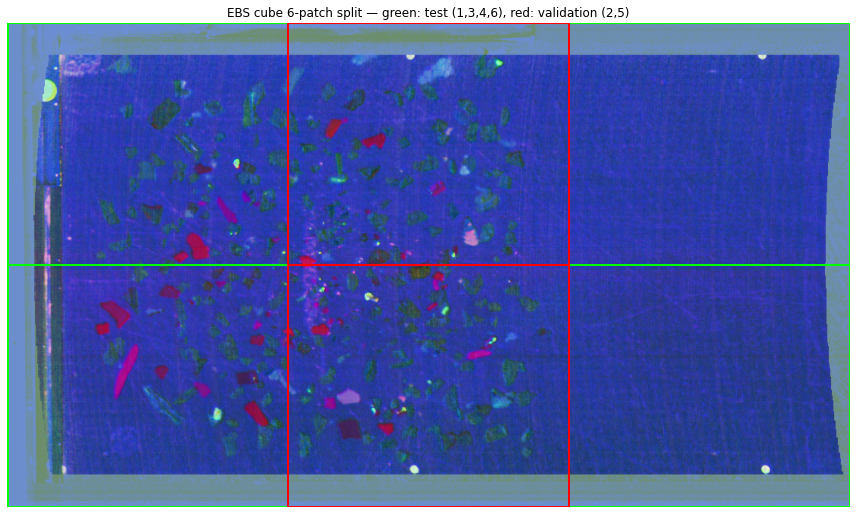

10 10


In [15]:
# 2) Extract train/test Data
_, Validation_patches, _, validation_patches_gt = patch_ebs_cubes_6_with_gt(Test_cubes, Test_cubes_gt, plot = True)
print(len(Validation_patches), len(validation_patches_gt))

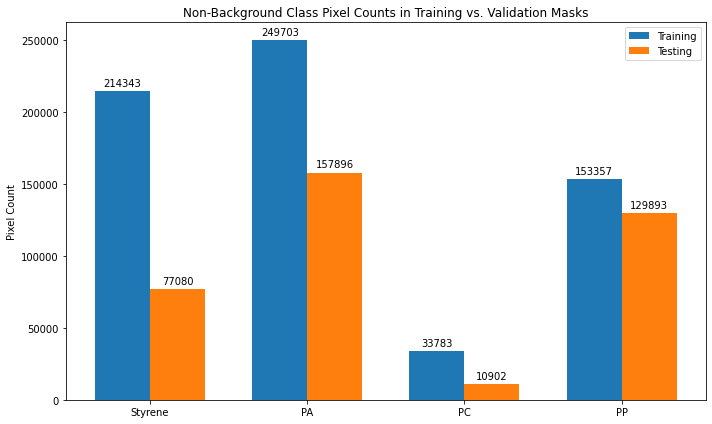

In [16]:
plot_non_background_statistics(Training_cubes_gt, Test_cubes_gt)

## Clean DL Pixel, Semantic-Object, and SAM-Instance Workflow

Run the setup cells above first, up to the creation of `Training_cubes`, `Training_cubes_gt`, `Test_cubes`, `Test_cubes_gt`, `Test_cubes_semantic_masks`, and `Test_cubes_instance_masks`.

In [17]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

from collections import Counter

class HSIDataset(Dataset):
    def __init__(self, hsi, gt, patch_size, times=1, fill_value_X=0, 
                 ignore_classes=[0], band_patch=1, augmentations=None, aug_prob=0.5):
        if isinstance(hsi, list):
            self.hsi_list = hsi
            self.gt_list = gt
        else:
            self.hsi_list = [hsi]
            self.gt_list = [gt]

        self.patch_size = patch_size
        self.times = times
        self.fill_value_X = fill_value_X
        self.ignore_classes = ignore_classes
        self.band_patch = band_patch
        self.augmentations = augmentations  # None = no augmentation (e.g. test set)
        self.aug_prob = aug_prob

        # Pre-pad all HSI cubes once
        center_offset = patch_size // 2
        self.padded_hsi_list = [
            np.pad(hsi, ((center_offset, center_offset), (center_offset, center_offset), (0, 0)),
                   mode='constant', constant_values=fill_value_X)
            for hsi in self.hsi_list
        ]

        # Base indices: one entry per valid pixel
        base_indices = self._collect_indices()
        self.original_patch_count = len(base_indices)

        # For training with times > 1: repeat indices so each pixel gets
        # `times` augmented versions drawn independently at __getitem__ time.
        # Index format: (cube_idx, row, col, label, is_augmented)
        if self.augmentations and self.times > 1:
            augmented_indices = [
                (cube_idx, i, j, label, True)
                for _ in range(self.times - 1)          # times-1 extra augmented copies
                for cube_idx, i, j, label in base_indices
            ]
            base_with_flag = [(c, i, j, l, False) for c, i, j, l in base_indices]
            self.indices = base_with_flag + augmented_indices
        else:
            self.indices = [(c, i, j, l, False) for c, i, j, l in base_indices]

    def _collect_indices(self):
        indices = []
        for cube_idx, (hsi, mask) in enumerate(zip(self.hsi_list, self.gt_list)):
            h, w = mask.shape
            for i in range(h):
                for j in range(w):
                    label = mask[i, j]
                    if label not in self.ignore_classes:
                        indices.append((cube_idx, i, j, label))
        return indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        cube_idx, i, j, label, is_augmented = self.indices[idx]

        # Extract patch on-the-fly
        padded = self.padded_hsi_list[cube_idx]
        patch = padded[i:i + self.patch_size, j:j + self.patch_size, :].copy()

        # Apply augmentations only when flagged (training copies) or
        # when augmentations are set and times == 1 (stochastic per epoch)
        if self.augmentations and (is_augmented or self.times == 1):
            patch = augment_hsi(patch, self.augmentations, prob=self.aug_prob)

        label = label - 1

        band = patch.shape[-1]
        patch = gain_neighborhood_band(
            np.expand_dims(patch, axis=0), band, self.band_patch, self.patch_size
        ).squeeze(0)
        patch = np.transpose(patch, (1, 0))

        return torch.tensor(patch, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

    def get_original_patch_count(self):
        return self.original_patch_count

/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
# Define the gain_neighborhood_band function
def gain_neighborhood_band(x_train, band, band_patch, patch):
    nn = band_patch // 2
    pp = (patch * patch) // 2
    x_train_reshape = x_train.reshape(x_train.shape[0], patch * patch, band)
    x_train_band = np.zeros((x_train.shape[0], patch * patch * band_patch, band), dtype=float)
    
    # Center region
    x_train_band[:, nn * patch * patch:(nn + 1) * patch * patch, :] = x_train_reshape
    
    # Left mirror
    for i in range(nn):
        if pp > 0:
            x_train_band[:, i * patch * patch:(i + 1) * patch * patch, :i + 1] = x_train_reshape[:, :, band - i - 1:]
            x_train_band[:, i * patch * patch:(i + 1) * patch * patch, i + 1:] = x_train_reshape[:, :, :band - i - 1]
        else:
            x_train_band[:, i:(i + 1), :(nn - i)] = x_train_reshape[:, 0:1, (band - nn + i):]
            x_train_band[:, i:(i + 1), (nn - i):] = x_train_reshape[:, 0:1, :(band - nn + i)]
    
    # Right mirror
    for i in range(nn):
        if pp > 0:
            x_train_band[:, (nn + i + 1) * patch * patch:(nn + i + 2) * patch * patch, :band - i - 1] = x_train_reshape[:, :, i + 1:]
            x_train_band[:, (nn + i + 1) * patch * patch:(nn + i + 2) * patch * patch, band - i - 1:] = x_train_reshape[:, :, :i + 1]
        else:
            x_train_band[:, (nn + 1 + i):(nn + 2 + i), (band - i - 1):] = x_train_reshape[:, 0:1, :(i + 1)]
            x_train_band[:, (nn + 1 + i):(nn + 2 + i), :(band - i - 1)] = x_train_reshape[:, 0:1, (i + 1):]
    
    return x_train_band


In [19]:
import gc
gc.collect()

0

In [20]:
from augmentations import *

# Set parameters
patch_size = 9 # For SpectralFormer pixel-wise make this value equals 1
band_patch = 7 # the Group Spectral Embedding parameter (its output shape doesn't make sense for Transformer encoders, 1 is the best value, since it means no GSE)
num_classes = 4
batch_size=512
# 
augmentations = [spectral_shift, spectral_smoothing, spectral_noise, spectral_scaling, spectral_channel_dropping] # x5
                #random_rotation, random_translation, random_flipping] #random_elastic_deformation
test_dataset = HSIDataset(Test_cubes, Test_cubes_gt, patch_size, augmentations = None, ignore_classes=[0], band_patch = band_patch)
print("Test set is finished \n")
print(f"test patches: Original - {test_dataset.get_original_patch_count()}, After Augmentation - {len(test_dataset)}")

val_dataset = HSIDataset(Validation_patches, validation_patches_gt, patch_size, times=1 , ignore_classes=[0], band_patch = band_patch)
print("Validation set is finished")
print(f"Validation patches: Original - {val_dataset.get_original_patch_count()}, After Augmentation - {len(val_dataset)}")
# Create dataset and dataloader for testing
print('\n')

train_dataset = HSIDataset(Training_cubes, Training_cubes_gt, patch_size, augmentations = None, times=1, ignore_classes=[0], band_patch=band_patch) # delete
print("Training set is finished")
print(f"Training patches: Original - {train_dataset.get_original_patch_count()}, After Augmentation - {len(train_dataset)}")
print('\n')

print(f"Combined Validation Dataset Size: {len(val_dataset)}")
label_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
label_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
label_test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



Test set is finished 

test patches: Original - 375771, After Augmentation - 375771
Validation set is finished
Validation patches: Original - 158143, After Augmentation - 158143


Training set is finished
Training patches: Original - 651186, After Augmentation - 651186


Combined Validation Dataset Size: 158143


In [21]:
i = 0
min_label = float('inf')
max_label = float('-inf')

for patch, label in label_train_loader:
    if i == 0:
        print("Patch shape:", patch.shape)
        print("Label shape:", label.shape)
    i+=1
    min_label = min(min_label, torch.min(label).item())
    max_label = max(max_label, torch.max(label).item())
    break
print(f"Min label: {min_label}")
print(f"Max label: {max_label}")

Patch shape: torch.Size([512, 143, 567])
Label shape: torch.Size([512])
Min label: 0
Max label: 3


In [22]:
from collections import Counter

def count_classes(gt_list, ignore_classes):
    class_counts = Counter()
    
    for mask in gt_list:
        # Flatten the mask and filter out ignored classes
        flattened_mask = mask.flatten()
        filtered_mask = [val for val in flattened_mask if val not in ignore_classes]
        
        # Update the class counts
        class_counts.update(filtered_mask)
    
    return class_counts

# Function to calculate class weights inversely proportional to their frequency
def calculate_class_weights(gt_list, ignore_classes):
    class_counts = count_classes(gt_list, ignore_classes)
    total_pixels = sum(class_counts.values())
    
    class_weights = {
        class_value: total_pixels / count
        for class_value, count in class_counts.items()
    }
    
    return class_weights

class_counts = count_classes(Training_cubes_gt, ignore_classes = [0])

# Print the class counts
print("Class counts excluding ignored classes:")
for class_value, count in sorted(class_counts.items()):
    print(f"Class {class_value}: {count}")

# Calculate and print class weights
class_weights = calculate_class_weights(Training_cubes_gt, ignore_classes = [0])
print("\nClass weights:")
for class_value, weight in sorted(class_weights.items()):
    print(f"Class {class_value}: {weight:.4f}")


Class counts excluding ignored classes:
Class 1: 214343
Class 2: 249703
Class 3: 33783
Class 4: 153357

Class weights:
Class 1: 3.0381
Class 2: 2.6078
Class 3: 19.2756
Class 4: 4.2462


In [23]:
# Normalizing the class weights

sorted_keys = sorted(class_weights.keys())  # e.g., [1, 2, 3, 4, 5]

# 2. Extract the weights in sorted order and make a NumPy array.
weights_array = np.array([class_weights[k] for k in sorted_keys])

# 3. Normalize the weights.
normalized_weights = weights_array*2 / weights_array.sum()
class_weights_tensor = torch.tensor(normalized_weights, dtype=torch.float32)

print("Normalized Class Weights:", len(class_weights), normalized_weights)

Normalized Class Weights: 4 [0.20831673 0.17881737 1.32170715 0.29115875]


In [24]:
# Function to train a model on a specific GPU
def set_gpu(gpu_id):
    """
    Function to set the current device to a specific GPU

    Parameters:
        gpu_id (int): The ID of the GPU to use

    Returns:
        torch.device: The selected GPU device
    """

    # Set the current device to the specified GPU ID
    torch.cuda.set_device(gpu_id)
    
    # Return the selected GPU device
    return torch.device("cuda")

In [25]:
import torch.backends.cudnn as cudnn
import torch.optim as optim
from models import ViT
import torch.nn as nn
def build_lr_scheduler(optimizer, total_epochs, decay_factor=0.9, decay_interval=None):
    """Build LR scheduler that decays by decay_factor every decay_interval epochs."""
    if decay_interval is None:
        decay_interval = total_epochs // 10
    def lr_lambda(epoch):
        return decay_factor ** (epoch // decay_interval)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

num_classes = 4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Run longer and keep the LR flat (no warmup/decay) to expose deep double descent
num_epochs = 300
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
cudnn.deterministic = True
cudnn.benchmark = False
# hsi_bands = Styrole_test[0].shape[-1]

# Model hyperparameters
VIT_DIM = 64
VIT_DEPTH = 5
VIT_HEADS = 4
VIT_MLP_DIM = 8
VIT_DROPOUT = 0.1
VIT_EMB_DROPOUT = 0.1
VIT_MODE = 'CAF'

# Training hyperparameters
BATCH_SIZE = batch_size
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-3
NUM_EPOCHS = 300
PATIENCE = 40
LR_DECAY_FACTOR = 0.9
LR_DECAY_INTERVAL = NUM_EPOCHS // 10  # Decay after each 1/10 of total epochs
TEST_EVAL_INTERVAL = 30  # Evaluate on test set every 30 epochs
TOTAL_BANDS = 143

# GSE value (fixed for this experiment)
GSE_VALUE = band_patch
patch_size = patch_size
num_classes = 4

# Single run (no K-fold)
LOG_DIR_EBS = "/home/arbash44/coding/hsi/polymers/EBS_only/trained_models/SF_patch_9"

model = ViT(
    image_size=patch_size,  # patch_size should be 1 or 3
    near_band=GSE_VALUE,
    num_patches=TOTAL_BANDS,
    num_classes=num_classes,
    dim=VIT_DIM,
    depth=VIT_DEPTH,
    heads=VIT_HEADS,
    mlp_dim=VIT_MLP_DIM,
    dropout=VIT_DROPOUT,
    emb_dropout=VIT_EMB_DROPOUT,
    mode=VIT_MODE
)
model = model.cuda()

# Print number of parameters in the model
num_params = sum(p.numel() for p in model.parameters())
print(f"Model has {num_params:,} parameters.")

# criterion
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)
# optimizer: higher LR, no decay to surface double descent behaviour
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = build_lr_scheduler(optimizer, NUM_EPOCHS, LR_DECAY_FACTOR, LR_DECAY_INTERVAL)

path = '/home/arbash44/coding/hsi/polymers/EBS_only/trained_models/SF_patch_9.pth' 

Model has 259,868 parameters.


In [26]:
# Training loop
best_epoch = 0
best_val_loss = float('inf')
patience = 10  # Number of epochs to wait for improvement
epochs_without_improvement = 0

# Move the model to GPU if available
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    train_loss = 0.0  # Initialize the training loss
    
    # Iterate over training batches
    for patch, label in label_train_loader:
        
        # Zero gradients for optimizer
        optimizer.zero_grad()

        # Move the data to GPU
        patch = patch.to(device)
        label = label.to(device)

        # Forward pass
        outputs = model(patch).to(device)
        loss = criterion(outputs, label)

        # Backpropagation and optimization
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights
        
        # Accumulate training loss
        train_loss += loss.item()

    # Print the average training loss for the epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss / len(label_train_loader):.4f}")

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0  # Initialize the validation loss
    
    # Disable gradient calculation (not needed for validation)
    with torch.no_grad():
        for patch, label in label_val_loader:
            # Move the data to GPU
            patch = patch.to(device)
            #label = label.type(torch.LongTensor)
            label = label.to(device)
            # Forward pass
            outputs = model(patch).to(device)
            
            # Calculate validation loss
            loss = criterion(outputs, label)
            val_loss += loss.item()

    scheduler.step(val_loss)
    # Print average validation loss for the epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss / len(label_val_loader):.4f}")

    # Check for improvement in validation loss
    if val_loss < best_val_loss:
        # Update best validation loss and epoch
        best_val_loss = val_loss
        best_epoch = epoch

        # Reset early stopping counter
        epochs_without_improvement = 0
        
        # Save model weights
        torch.save(model.state_dict(), path)
        print(f"Best Epoch so far [{epoch+1}/{num_epochs}], Best Validation Loss so far: {val_loss / len(label_val_loader):.4f}")
    else:
        # Increment early stopping counter
        epochs_without_improvement += 1
    
    # Trigger early stopping if there are no improvements for `patience` epochs
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered. No improvement in {patience} epochs.")
        break

# Print best epoch and corresponding validation loss
print(f"Best Epoch: {best_epoch + 1}, Best Validation Loss: {best_val_loss / len(label_val_loader):.4f}")

Epoch [1/300], Train Loss: 0.1402
Epoch [1/300], Validation Loss: 0.4441
Best Epoch so far [1/300], Best Validation Loss so far: 0.4441


/opt/conda/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:156: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
/opt/conda/lib/python3.8/site-packages/torch/nn/modules/module.py:1402: UserWarning: positional arguments and argument "destination" are deprecated. nn.Module.state_dict will not accept them in the future. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# # Load the trained weights
# model.load_state_dict(torch.load(path))

# # Move the model to the GPU if available
# # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # Set the model in evaluation mode: disables certain training-related features
# model.eval()

# x = 0

# # Initialize lists to store predicted masks
# predictions = []
# all_labels = []
# # Iterate over the test images and their ground truth masks
# for patch, label in label_test_loader:
        
#     # Move the data to GPU
#     patch = patch.to(device)  # Transfer the image data to the specified device
#     #masks = masks.type(torch.LongTensor)  # Convert the ground truth masks to LongTensor format
#     label = label.to(device)  # Transfer the ground truth masks to the specified device

# #     # Perform inference
#     with torch.no_grad():  # Forward pass the images through the model to obtain the predictions
#         output = model(patch)  # Forward pass the images through the model to obtain the predictions 

#     output = torch.nn.functional.softmax(output, dim=1)
#     output = torch.argmax(output, dim=1)
# #     with torch.no_grad():
# #         output = model(patch)
# #         print("Raw output logits:", output)
# #         print(output.shape)
# #         output = torch.nn.functional.softmax(output, dim=1)
# #         output = torch.argmax(output, dim=1)
# #         print("Processed output:", output)
# #         print(output.shape)
# #         break
    
#     # Transfer the output to CPU memory and convert it to a numpy array
#     predicted_label = output.cpu().numpy()  
    
#     # Append the predicted mask to the list
#     predictions.append(predicted_label)
#     all_labels.append(label.cpu().flatten())
#     x = x + 512
#     x = x/ len(test_dataset)
#     print(x, "%")

In [ ]:
# 1) Helper functions: vector extraction, map reconstruction, and evaluation

from sklearn.metrics import confusion_matrix

CLASS_LABELS = [1, 2, 3, 4]
CLASS_NAMES = ['Styrene', 'PA', 'PC', 'PP']
BACKGROUND_LABEL = 0
EVALUATION_LABELS = [BACKGROUND_LABEL] + CLASS_LABELS



def prepare_model_batch(patches, patch_size, band_patch):
    """Apply the same SpectralFormer preprocessing used by HSIDataset.__getitem__."""
    band = patches.shape[-1]
    patches = gain_neighborhood_band(patches, band, band_patch, patch_size)
    return np.transpose(patches, (0, 2, 1))


def predict_maps(
    model,
    cubes,
    gt_maps,
    device='cuda',
    patch_size=patch_size,
    band_patch=band_patch,
    batch_size=512,
    ignore_labels=(BACKGROUND_LABEL,),
    output_label_offset=1,
):
    """
    Predict full-size maps from the DL model.

    HSIDataset trains with GT labels shifted down by 1, so model outputs 0..3.
    output_label_offset shifts predictions back to the expert GT labels 1..4.
    """
    pred_maps = []
    model.eval()

    for cube, gt_map in zip(cubes, gt_maps):
        cube = np.asarray(cube)
        gt_map = np.asarray(gt_map)

        if cube.shape[:2] != gt_map.shape:
            raise ValueError(f'Cube and GT shapes do not match: {cube.shape[:2]} vs {gt_map.shape}')

        pred_map = np.zeros(gt_map.shape, dtype=np.int64)
        eval_mask = ~np.isin(gt_map, ignore_labels)
        rows, cols = np.where(eval_mask)

        if len(rows) == 0:
            pred_maps.append(pred_map)
            continue

        pad = patch_size // 2
        padded_cube = np.pad(cube, ((pad, pad), (pad, pad), (0, 0)), mode='constant', constant_values=0)

        for start in range(0, len(rows), batch_size):
            end = min(start + batch_size, len(rows))
            batch_rows = rows[start:end]
            batch_cols = cols[start:end]

            patches = np.stack([
                padded_cube[row:row + patch_size, col:col + patch_size, :]
                for row, col in zip(batch_rows, batch_cols)
            ])
            patches = prepare_model_batch(patches, patch_size, band_patch)
            patches = torch.from_numpy(patches).float().to(device)

            with torch.no_grad():
                logits = model(patches)
                pred_labels = torch.argmax(logits, dim=1).cpu().numpy() + output_label_offset

            pred_map[batch_rows, batch_cols] = pred_labels

        pred_maps.append(pred_map)

    return pred_maps


def evaluate_maps(gt_maps, pred_maps, labels=EVALUATION_LABELS, class_labels=CLASS_LABELS, ignore_labels=(BACKGROUND_LABEL,)):
    """Evaluate maps on non-background GT pixels while counting background predictions as errors."""
    y_true_parts = []
    y_pred_parts = []

    for gt_map, pred_map in zip(gt_maps, pred_maps):
        gt_map = np.asarray(gt_map)
        pred_map = np.asarray(pred_map)

        if gt_map.shape != pred_map.shape:
            raise ValueError(f'GT and prediction shapes do not match: {gt_map.shape} vs {pred_map.shape}')

        eval_mask = ~np.isin(gt_map, ignore_labels)
        y_true_parts.append(gt_map[eval_mask])
        y_pred_parts.append(pred_map[eval_mask])

    y_true = np.concatenate(y_true_parts)
    y_pred = np.concatenate(y_pred_parts)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    eps = 1e-10
    label_to_index = {label: index for index, label in enumerate(labels)}
    class_indices = [label_to_index[label] for label in class_labels]

    tp = np.diag(cm)[class_indices]
    fp = cm[:, class_indices].sum(axis=0) - tp
    fn = cm[class_indices, :].sum(axis=1) - tp

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    oa = tp.sum() / (cm.sum() + eps)
    aa = recall.mean()

    return {
        'labels': labels,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'iou': iou,
        'OA': oa,
        'AA': aa,
    }


def print_evaluation(title, results):
    print(title)
    print('Labels:', results['labels'])
    print('Confusion Matrix:')
    print(results['confusion_matrix'])
    print('OA:', results['OA'])
    print('AA:', results['AA'])
    print('Precision:', dict(zip(CLASS_NAMES, results['precision'])))
    print('Recall:', dict(zip(CLASS_NAMES, results['recall'])))
    print('F1:', dict(zip(CLASS_NAMES, results['f1_score'])))
    print('IoU:', dict(zip(CLASS_NAMES, results['iou'])))

In [ ]:
# 4) Pixel-wise prediction and pixel-wise evaluation

pixel_pred_maps = predict_maps(model, Test_cubes, Test_cubes_gt)
pixel_results = evaluate_maps(Test_cubes_gt, pixel_pred_maps)

print_evaluation('Pixel-wise DL evaluation', pixel_results)

In [ ]:
# 5) Optional: visualize one pixel-wise prediction map

sample_idx = 1
print('Sample index:', sample_idx)
print('Ground truth labels:', np.unique(Test_cubes_gt[sample_idx], return_counts=True))
print('Prediction labels:', np.unique(pixel_pred_maps[sample_idx], return_counts=True))

visualize_mask(Test_cubes_gt[sample_idx])
visualize_mask(pixel_pred_maps[sample_idx])

In [ ]:
# 6) Semantic-segmentation majority voting on pixel-wise prediction maps

semantic_majority_maps = [
    majority_vote_semantic_objects(pred_map, semantic_mask, ignore_labels=(BACKGROUND_LABEL,))
    for pred_map, semantic_mask in zip(pixel_pred_maps, Test_cubes_semantic_masks)
]

gt_semantic_majority_maps = [
    majority_vote_semantic_objects(pred_map, semantic_mask, ignore_labels=(BACKGROUND_LABEL,))
    for pred_map, semantic_mask in zip(Test_cubes_gt, Test_cubes_semantic_masks)
]

semantic_results = evaluate_maps(gt_semantic_majority_maps, semantic_majority_maps)
print_evaluation('Semantic-object majority voting evaluation', semantic_results)

visualize_mask(semantic_majority_maps[sample_idx])

In [ ]:
# 7) SAM-instance majority voting on pixel-wise prediction maps

sam_instance_majority_maps = [
    majority_vote_sam_instances(
        pred_map,
        instances,
        ignore_labels=(BACKGROUND_LABEL,),
        overwrite_overlaps=False,
    )
    for pred_map, instances in zip(pixel_pred_maps, Test_cubes_instance_masks)
]

gt_sam_instance_majority_maps = [
    majority_vote_sam_instances(
        pred_map,
        instances,
        ignore_labels=(BACKGROUND_LABEL,),
        overwrite_overlaps=False,
    )
    for pred_map, instances in zip(Test_cubes_gt, Test_cubes_instance_masks)
]


sam_instance_results = evaluate_maps(gt_sam_instance_majority_maps, sam_instance_majority_maps)
print_evaluation('SAM-instance majority voting evaluation', sam_instance_results)

visualize_mask(sam_instance_majority_maps[sample_idx])

In [ ]:
# 8) Quick comparison of the three evaluation stages

summary = {
    'Pixel-wise KNN': pixel_results,
    'Semantic majority': semantic_results,
    'SAM-instance majority': sam_instance_results,
}

for name, result in summary.items():
    # Handle the case where result['f1_score'] is a numpy array
    f1_score = result['f1_score']
    if hasattr(f1_score, "item") and f1_score.shape == ():
        f1_score = f1_score.item()  # scalar numpy array
    elif hasattr(f1_score, "__len__") and not isinstance(f1_score, str):
        try:
            # Try to average across all classes if it's a vector
            f1_score = float(np.mean(f1_score))
        except Exception:
            # fallback to string representation if something goes wrong
            pass

    print(f"{name}: OA={result['OA']:.4f}, AA={result['AA']:.4f}, f1_score={f1_score:.4f}")

In [ ]:
# 5) Optional: visualize one pixel-wise prediction map

sample_idx = -1
print('Sample index:', sample_idx)
print('Ground truth labels:', np.unique(Test_cubes_gt[sample_idx], return_counts=True))
print('Prediction labels:', np.unique(pixel_pred_maps[sample_idx], return_counts=True))

visualize_mask(Test_cubes_gt[sample_idx])
visualize_mask(pixel_pred_maps[sample_idx])
visualize_mask(semantic_majority_maps[sample_idx])
visualize_mask(sam_instance_majority_maps[sample_idx])